# День 7 — Финализация mini-product

Сводка по всему проекту: полный цикл **data → preprocessing → baseline → improvement → error analysis → inference**.

Полное описание — в корневом [README](../README.md).

In [1]:
import sys, os
# Добавляем корень проекта в путь, чтобы импортировать модули (config, preprocess, ...)
sys.path.insert(0, os.path.abspath('..'))

In [2]:
from pathlib import Path
from IPython.display import Image, display
from config import REPORTS_DIR

## 1. Baseline

In [3]:
print((REPORTS_DIR / 'baseline_result.txt').read_text(encoding='utf-8'))

=== Baseline: TF-IDF (1,2) + LogisticRegression(balanced) ===
Train size: 4257, Test size: 1065

              precision    recall  f1-score   support

    negative     0.4901    0.6271    0.5502       118
     neutral     0.8204    0.8247    0.8225       576
    positive     0.7254    0.6550    0.6884       371

    accuracy                         0.7437      1065
   macro avg     0.6786    0.7023    0.6870      1065
weighted avg     0.7507    0.7437    0.7456      1065

Baseline macro F1: 0.6870



## 2. Сравнение подходов

In [4]:
print((REPORTS_DIR / 'improvement_comparison.txt').read_text(encoding='utf-8'))

=== День 4 — сравнение подходов (один и тот же test set) ===

| Метод | Macro F1 | Улучшение |
|-------|----------|-----------|
| Baseline: TF-IDF(1,2) + LogReg | 0.6870 | - |
| TF-IDF(1,3) + LinearSVC | 0.6646 | -2.24% |
| TF-IDF(1,2) sublinear + LogReg | 0.6948 | +0.78% |
| Word+Char TF-IDF + LinearSVC | 0.6800 | -0.70% |
| Word+Char + LinearSVC (tuned C=0.5) | 0.6983 | +1.13% |

Лучший метод: Word+Char + LinearSVC (tuned C=0.5) (macro F1 = 0.6983, +1.13% к baseline).

Что помогло: символьные n-граммы устойчивы к опечаткам/тикерам и формам слов; LinearSVC хорошо работает на разреженных TF-IDF; class_weight='balanced' поднимает recall редкого класса negative. Триграммы отдельно почти не помогли.


## 3. Error analysis

In [5]:
print((REPORTS_DIR / 'error_analysis.txt').read_text(encoding='utf-8'))

=== День 5 — Error analysis (best model) ===

Всего в test: 1065, ошибок: 241 (22.6%)

Classification report:
              precision    recall  f1-score   support

    negative     0.5283    0.4746    0.5000       118
     neutral     0.8167    0.8507    0.8333       576
    positive     0.7744    0.7493    0.7616       371

    accuracy                         0.7737      1065
   macro avg     0.7064    0.6915    0.6983      1065
weighted avg     0.7700    0.7737    0.7714      1065

Confusion matrix (строки=true, столбцы=pred):
             negative    neutral   positive
  negative         56         37         25
   neutral         30        490         56
  positive         20         73        278

Самые частые типы ошибок (true -> pred):
  positive -> neutral: 73
  neutral -> positive: 56
  negative -> neutral: 37
  neutral -> negative: 30
  negative -> positive: 25
  positive -> negative: 20

Примеры ошибок:

[positive -> neutral]
  - The court found TelecomInvest 's arguments 

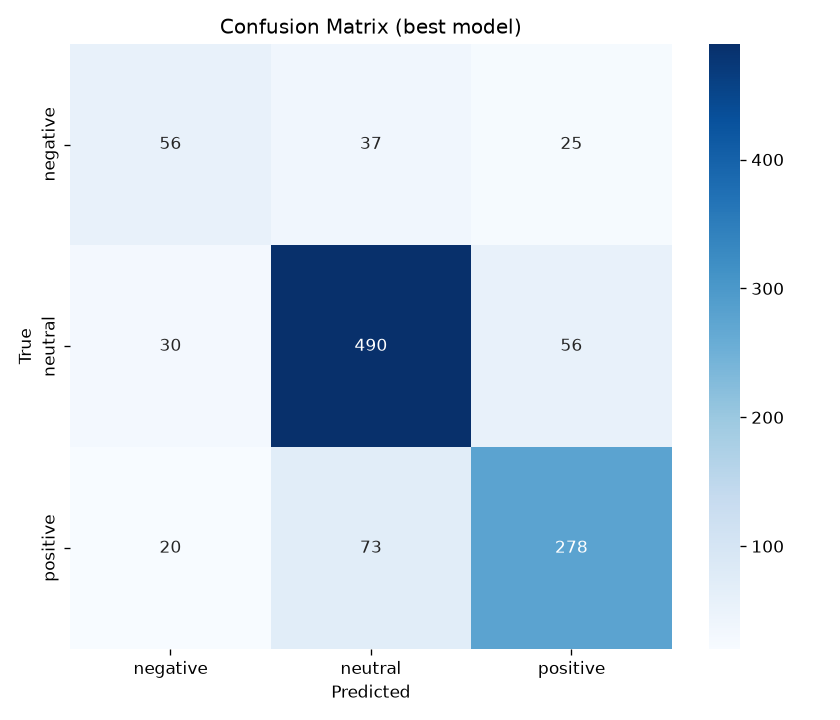

In [6]:
display(Image(str(REPORTS_DIR / 'confusion_matrix.png')))

## 4. Живой inference

In [7]:
import pandas as pd
from predict import predict_sentiment
demo = ['Profits jumped to a record high', 'The firm filed for bankruptcy', 'Results were in line with forecasts']
pd.DataFrame(predict_sentiment(demo))[['sentiment', 'confidence', 'text']]

,sentiment,confidence,text
0,positive,0.8888,Profits jumped to a record high
1,neutral,0.6510,The firm filed for bankruptcy
2,neutral,0.4772,Results were in line with forecasts


## Ограничения
- Классическая модель (TF-IDF + линейный классификатор): не улавливает контекст/сарказм.
- Только английский, стиль новостных заголовков.
- `negative` предсказывается менее надёжно (дисбаланс классов).
- Не является инвестиционной рекомендацией — учебный проект.